## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
from funcoes_psi import *
from funcoes_escoragem import *

## Diretório

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Variáveis Blend4 - Desenvolvimento

In [5]:
project_id = 'loft-dl-datascience'

query = '''
select * from loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527
'''

df_raw = pd.read_gbq(query, project_id=project_id)
df_raw

KeyboardInterrupt: 

In [ ]:
df_dev_blend4 = df_raw.copy()
df_dev_blend4["safra"] = df_dev_blend4["requested_at"].astype(str).str[:7]
df_dev_blend4 = df_dev_blend4[df_dev_blend4["safra"] <= "2025-08"]
df_dev_blend4

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,30.0,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN,2024-09
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,20.0,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN,2024-09
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0,2024-09
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0,2024-09
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,27.0,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0,2024-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356517,3076096,2025-08-31,2025-08-01,174.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,32.0,1.0,10.0,1470.0,2260.5,NaN,0.119675,0.0,0.0,2025-08
1356518,3076104,2025-08-31,2025-08-01,817.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,59.0,1.0,0.0,2677.5,11713.5,NaN,0.108987,0.0,0.0,2025-08
1356519,3076105,2025-08-31,2025-08-01,335.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,20.0,1.0,0.0,1627.5,1781.0,NaN,0.110814,0.0,0.0,2025-08
1356520,3076115,2025-08-31,2025-08-01,278.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,22.0,1.0,0.0,1680.0,1644.0,NaN,0.115226,0.0,0.0,2025-08


In [ ]:
bvs = pd.to_numeric(df_dev_blend4["score_proposto__bvs"], errors="coerce")
score = pd.to_numeric(df_dev_blend4["pred_blend4_1_to_score"], errors="coerce")

conditions = [
    bvs <= 334,                         # corte customizado BVS → E
    score.between(763, 1000),           # 763 – 1000
    score.between(704, 762),            # 704 – 762
    score.between(653, 703),            # 653 – 703
    score.between(607, 652),            # 607 – 652
    score.between(562, 606),            # 562 – 606
    score.between(520, 561),            # 520 – 561
    score.between(480, 519),            # 480 – 519
    score.between(443, 479),            # 443 – 479
    score.between(408, 442),            # 408 – 442
    score.between(375, 407),            # 375 – 407
    score.between(343, 374),            # 343 – 374
    score.between(307, 342),            # 307 – 342
    score.between(0, 306),              # 0 – 306
]

choices = [
    "9.E.BVS",      # override BVS ≤ 334
    "1.A+",
    "2.A",
    "2.A",
    "3.B+",
    "3.B+",
    "4.B",
    "4.B",
    "5.C",
    "6.D+",
    "7.D",
    "7.D",
    "8.E",
    "8.E",
]

df_dev_blend4["rating_pol_blend4"] = np.select(conditions, choices, default=None)

## Distribuição Ratings - Salvar

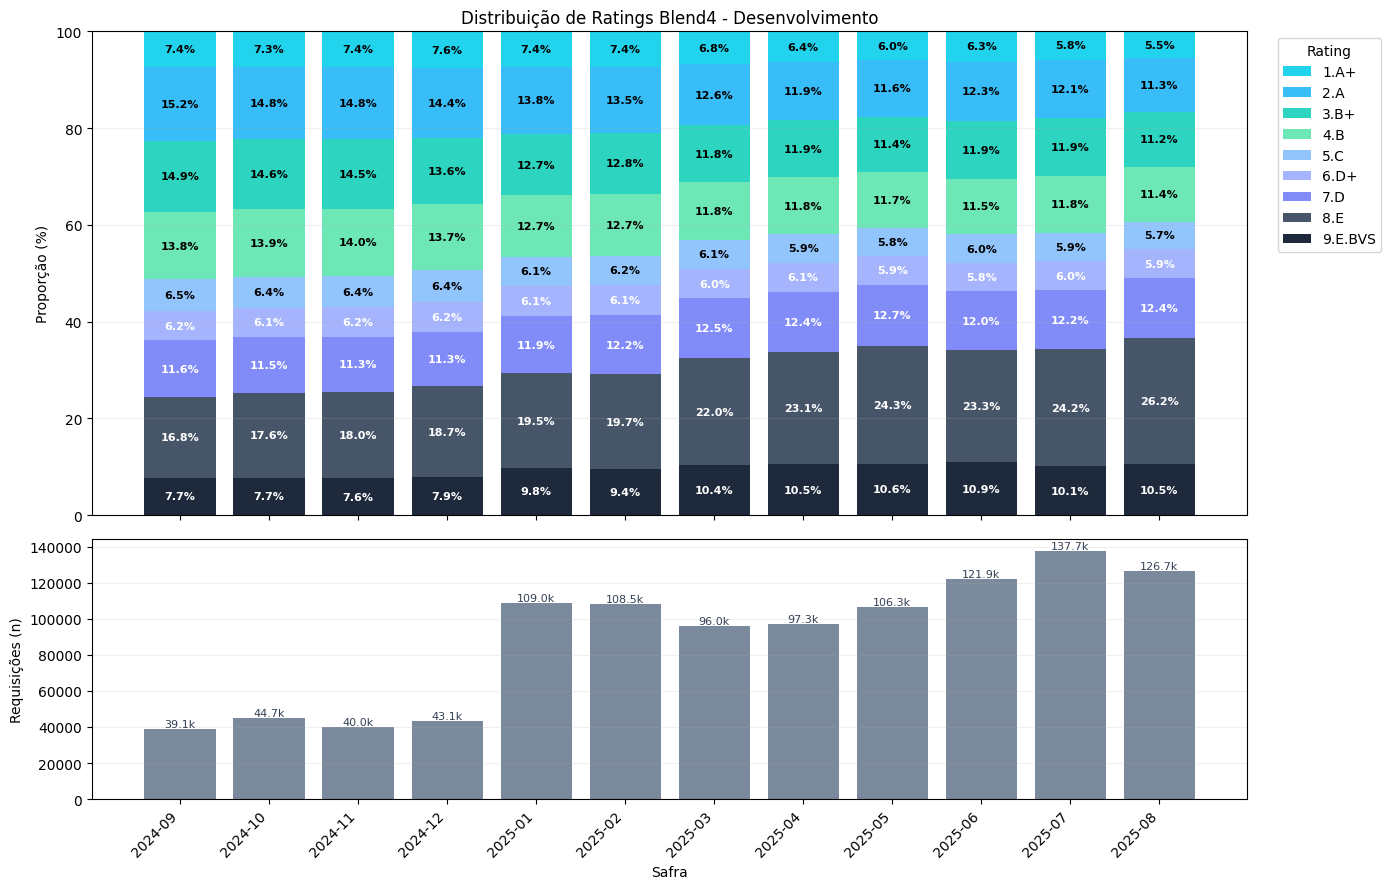

In [ ]:
from funcoes_monitoramento import plot_mix_and_volume

RATING_CL_POL_ORDER = [
    "1.A+", "2.A", "3.B+", "4.B", "5.C",
    "6.D+", "7.D", "8.E", "9.E.BVS",
]

RATING_CL_POL_COLOR_MAP = {
    "1.A+": "#22D3EE", "2.A": "#38BDF8", "3.B+": "#2DD4BF",
    "4.B": "#6EE7B7", "5.C": "#93C5FD", "6.D+": "#A5B4FC",
    "7.D": "#818CF8", "8.E": "#475569", "9.E.BVS": "#1E293B",
}

RATING_CL_POL_TEXT_COLOR_MAP = {
    "1.A+": "black", "2.A": "black", "3.B+": "black",
    "4.B": "black", "5.C": "black", "6.D+": "white",
    "7.D": "white", "8.E": "white", "9.E.BVS": "white",
}

plot_df = df_dev_blend4.dropna(subset=["rating_pol_blend4", "safra"]).copy()
plot_df["safra"] = plot_df["safra"].astype(str)
safra_order = sorted(plot_df["safra"].unique())

pct_df = (
    pd.crosstab(plot_df["safra"], plot_df["rating_pol_blend4"], normalize="index")
    .mul(100)
    .reindex(index=safra_order)
    .reindex(columns=RATING_CL_POL_ORDER, fill_value=0)
)

volume = plot_df.groupby("safra").size().reindex(safra_order, fill_value=0)

plot_mix_and_volume(
    pct_df,
    volume,
    title="Distribuição de Ratings Blend4 - Desenvolvimento",
    xlabel="Safra",
    category_order=RATING_CL_POL_ORDER,
    color_map=RATING_CL_POL_COLOR_MAP,
    text_color_map=RATING_CL_POL_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Rating",
    min_label_pct=3.0,
)
plt.show()

In [ ]:
pct_df

rating_pol_blend4,1.A+,2.A,3.B+,4.B,5.C,6.D+,7.D,8.E,9.E.BVS
safra,,,,,,,,,
2024-09,7.397561,15.175992,14.856471,13.846783,6.451778,6.168043,11.625470,16.776156,7.701746
2024-10,7.330487,14.833114,14.645324,13.947821,6.398247,6.053967,11.490912,17.573942,7.726185
2024-11,7.427314,14.752131,14.459639,13.962151,6.404840,6.192345,11.267218,17.967051,7.567311
2024-12,7.603344,14.442638,13.646075,13.722712,6.444496,6.223874,11.314445,18.704134,7.898281
2025-01,7.351552,13.820624,12.712479,12.695966,6.083790,6.143417,11.877700,19.528304,9.786168
2025-02,7.398159,13.522902,12.760880,12.659523,6.163443,6.111843,12.239351,19.707538,9.436361
2025-03,6.804974,12.575767,11.831115,11.848820,6.090525,6.005124,12.459122,22.019830,10.364723
2025-04,6.370160,11.931199,11.890075,11.751280,5.885921,6.062756,12.445253,23.132441,10.530915
2025-05,5.972157,11.638604,11.378045,11.663061,5.819772,5.920421,12.697771,24.315681,10.594488


In [ ]:
df = pct_df.join(pd.DataFrame(volume).rename(columns={0: "volume"}), on="safra", how="left")
df

,1.A+,2.A,3.B+,4.B,5.C,6.D+,7.D,8.E,9.E.BVS,volume
safra,,,,,,,,,,
2024-09,7.397561,15.175992,14.856471,13.846783,6.451778,6.168043,11.625470,16.776156,7.701746,39121
2024-10,7.330487,14.833114,14.645324,13.947821,6.398247,6.053967,11.490912,17.573942,7.726185,44731
2024-11,7.427314,14.752131,14.459639,13.962151,6.404840,6.192345,11.267218,17.967051,7.567311,40001
2024-12,7.603344,14.442638,13.646075,13.722712,6.444496,6.223874,11.314445,18.704134,7.898281,43060
2025-01,7.351552,13.820624,12.712479,12.695966,6.083790,6.143417,11.877700,19.528304,9.786168,109011
2025-02,7.398159,13.522902,12.760880,12.659523,6.163443,6.111843,12.239351,19.707538,9.436361,108527
2025-03,6.804974,12.575767,11.831115,11.848820,6.090525,6.005124,12.459122,22.019830,10.364723,96018
2025-04,6.370160,11.931199,11.890075,11.751280,5.885921,6.062756,12.445253,23.132441,10.530915,97266
2025-05,5.972157,11.638604,11.378045,11.663061,5.819772,5.920421,12.697771,24.315681,10.594488,106310


In [ ]:
df.to_csv(ANALYTICS_DIR/"dev_rating_pol_blend4.csv")

## Restrição BVS e Preparação de Variáveis

In [ ]:
df_dev_blend4 = df_dev_blend4[df_dev_blend4["score_proposto__bvs"] > 334]
# df_predict = prepare_blend4_variables(df_dev_blend4)
# df_predict = predict_blend4_1(df_predict_vars)

## Base Blend4 em Produção

In [ ]:
df_prod = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")
df_prod = df_prod[df_prod["REGRA_BLEND_4"] == "BLEND4"].copy()
df_prod

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,age__normalized4_1,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4,rating_cl_pol_blend4
0,33105054804,4152079,2026-06-18,2026-06-18,1,NI,BLEND3_3,5971967,32,33105054804,...,0.55,0.0,-0.558874,0.000000,0.000000,0.477315,523.0,A,A,6.B
1,7691151527,4156419,2026-06-16,2026-06-16,1,NI,BLEND3_3,5956396,34,7691151527,...,-0.50,2.0,-0.277898,0.000000,0.000000,0.499599,500.0,A,B,7.B
2,40664954863,4159085,2026-06-18,2026-06-18,1,E,BLEND3_3,5967580,34,40664954863,...,0.05,0.0,0.662630,0.018516,0.625237,0.582800,417.0,C,E,9.D+
3,12490765957,4165665,2026-06-12,2026-06-20,1,NI,BLEND3_3,5978513,34,12490765957,...,-0.45,0.0,10.566962,0.000000,1.464816,0.774663,225.0,E,E,E-2.E
4,12010654536,4167478,2026-06-15,2026-06-15,1,NI,BLEND3_3,5949536,34,12010654536,...,-0.75,0.0,0.452325,0.000000,0.000000,0.501865,498.0,A,A,7.B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111990,8227376983,4345686,2026-07-07,2026-07-07,1,D,BLEND3_3,6062771,33,8227376983,...,0.00,3.0,2.555369,0.000000,1.246605,0.633352,367.0,D,E,11.D
111991,48788388840,4345766,2026-07-07,2026-07-07,1,F,BLEND3_3,6062870,33,48788388840,...,-0.65,3.0,0.443876,0.000000,0.124206,0.548543,451.0,B,E,8.C
111992,47313079885,4345814,2026-07-07,2026-07-07,1,A,BLEND3_3,6063099,32,47313079885,...,-0.30,0.0,1.243070,0.000000,-0.501770,0.522669,477.0,B,A,8.C
111993,62043840312,4345874,2026-07-07,2026-07-07,1,NI,BLEND3_3,6063022,34,62043840312,...,-0.40,0.0,0.227300,0.000000,0.768522,0.543542,456.0,B,C,8.C


## PSI de Variáveis: Treino/Teste e OOT

In [ ]:
# model_vars = [
#     "score_proposto__bvs__normalized4_1",
#     "SERASA_CHSV5__normalized4_1",
#     "age__normalized4_1",
#     "property_type",
#     "qtde_restricoes__consulta_realizada__normalized4_1",
#     "income_commitment__normalized4_1",
#     "agency_pc4_mais_100_contratos__pc_categorias__normalized4_1",
#     "city_pc4_mais_100_contratos__pc_categorias__normalized4_1",
#     "flag_tem__contratos_anteriores",
#     "flag_teve_boleto_atrasado__contratos_anteriores",
#     "agency_pc4_mais_100_contratos__pc_categorias_is_null",
#     "city_pc4_mais_100_contratos__pc_categorias_is_null",
#     "pred_blend4_1_to_score",
# ]

In [ ]:
model_vars = [
    "score_proposto__bvs",
    "SERASA_CHSV5",
    "age",
    "property_type",
    "qtde_restricoes__consulta_realizada",
    "income_commitment",
    "agency_pc4_mais_100_contratos__pc_categorias",
    "city_pc4_mais_100_contratos__pc_categorias",
    "flag_tem__contratos_anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    "city_pc4_mais_100_contratos__pc_categorias_is_null",
    "pred_blend4_1_to_score",
]

In [ ]:
df = df_dev_blend4.copy()

In [ ]:
df["income_commitment"] = df["rental_value"] / df["income"]
df["income_commitment"] = df["income_commitment"].replace([np.inf, -np.inf], np.nan)

fill_dict_blend4_1 = ({
    "property_type": 1,
    "flag_tem__contratos_anteriores": 0,
    "flag_teve_boleto_atrasado__contratos_anteriores": 0,
})

cols_flag = [
    "city_pc4_mais_100_contratos__pc_categorias",
    "agency_pc4_mais_100_contratos__pc_categorias",
]

for col in cols_flag:
    df[f"{col}_is_null"] = df[col].isna().astype(int)

# Null flags (before imputation)
df = df.fillna(fill_dict_blend4_1)

In [ ]:
from funcoes_psi import (
    calculate_development_psi_baselines,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

train_mask = df_dev_blend4["FLAG_TESTE"] == 0
test_mask = df_dev_blend4["FLAG_TESTE"] == 1
oot_mask = df_dev_blend4["FLAG_OOT"] == 1

psi_baseline_long, psi_reference_artifact = calculate_development_psi_baselines(
    df=df,
    variables=model_vars,
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_1",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "FLAG_TESTE == 0",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
2,agency_pc4_mais_100_contratos__pc_categorias,0.072770,0.000840
4,city_pc4_mais_100_contratos__pc_categorias,0.066519,0.000077
9,pred_blend4_1_to_score,0.023760,0.000040
11,qtde_restricoes__consulta_realizada,0.023589,0.000028
0,SERASA_CHSV5,0.020552,0.000130
12,score_proposto__bvs,0.010233,0.000116
10,property_type,0.002975,0.000004
3,agency_pc4_mais_100_contratos__pc_categorias_i...,0.001303,0.000000
1,age,0.001148,0.000071
8,income_commitment,0.000865,0.000048


In [ ]:
# from funcoes_psi import (
#     calculate_development_psi_baselines,
#     pivot_psi_baseline,
#     save_psi_reference,
#     BINARY_MODEL_VARS,
# )

# train_mask = df_dev_blend4["FLAG_TESTE"] == 0
# test_mask = df_dev_blend4["FLAG_TESTE"] == 1
# oot_mask = df_dev_blend4["FLAG_OOT"] == 1

# psi_baseline_long, psi_reference_artifact = calculate_development_psi_baselines(
#     df=df_predict,
#     variables=model_vars,
#     train_mask=train_mask,
#     test_mask=test_mask,
#     oot_mask=oot_mask,
#     n_bins=10,
#     binary_vars=BINARY_MODEL_VARS,
#     metadata={
#         "model": "blend4_1",
#         "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
#         "reference_split": "FLAG_TESTE == 0",
#         "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
#     },
# )

# psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
# psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

## Salvar Artefatos

In [ ]:
from funcoes_psi import (
    calculate_development_psi_baselines_final,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

psi_reference_artifact = calculate_development_psi_baselines_final(
    df=df,
    variables=model_vars,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_1",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Treino_Teste_OOT",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
2,agency_pc4_mais_100_contratos__pc_categorias,0.072770,0.000840
4,city_pc4_mais_100_contratos__pc_categorias,0.066519,0.000077
9,pred_blend4_1_to_score,0.023760,0.000040
11,qtde_restricoes__consulta_realizada,0.023589,0.000028
0,SERASA_CHSV5,0.020552,0.000130
12,score_proposto__bvs,0.010233,0.000116
10,property_type,0.002975,0.000004
3,agency_pc4_mais_100_contratos__pc_categorias_i...,0.001303,0.000000
1,age,0.001148,0.000071
8,income_commitment,0.000865,0.000048


In [ ]:
# from funcoes_psi import (
#     calculate_development_psi_baselines_final,
#     pivot_psi_baseline,
#     save_psi_reference,
#     BINARY_MODEL_VARS,
# )

# psi_reference_artifact = calculate_development_psi_baselines_final(
#     df=df_predict,
#     variables=model_vars,
#     n_bins=10,
#     binary_vars=BINARY_MODEL_VARS,
#     metadata={
#         "model": "blend4_1",
#         "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
#         "reference_split": "Treino_Teste_OOT",
#         "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
#     },
# )

# psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
# psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

In [ ]:
# Save single artifact + baseline table
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_psi_reference.pkl"
PSI_BASELINE_PATH = ANALYTICS_DIR / "blend4_psi_baseline_ref.csv"

save_psi_reference(psi_reference_artifact, PSI_REFERENCE_PATH)
psi_baseline_ref.to_csv(PSI_BASELINE_PATH, index=False)

print(f"Saved artifact: {PSI_REFERENCE_PATH}")
print(f"Saved baseline: {PSI_BASELINE_PATH}")

Saved artifact: data/analytics/blend4_psi_reference.pkl
Saved baseline: data/analytics/blend4_psi_baseline_ref.csv


In [ ]:
psi_reference_artifact["variables"]["agency_pc4_mais_100_contratos__pc_categorias"]

{'type': 'quantile',
 'edges': [-inf,
  0.06649616368286443,
  0.08737864077669905,
  0.10000000000000003,
  0.11538461538461539,
  0.13068181818181818,
  0.14440433212996404,
  0.16470588235294129,
  0.1899109792284868,
  0.22666666666666668,
  inf],
 'bin_labels': ['(-inf, 0.066496]',
  '(0.066496, 0.087379]',
  '(0.087379, 0.100000]',
  '(0.100000, 0.115385]',
  '(0.115385, 0.130682]',
  '(0.130682, 0.144404]',
  '(0.144404, 0.164706]',
  '(0.164706, 0.189911]',
  '(0.189911, 0.226667]',
  '(0.226667, inf]'],
 'expected_counts': {'(-inf, 0.066496]': 19322,
  '(0.066496, 0.087379]': 18631,
  '(0.087379, 0.100000]': 18969,
  '(0.100000, 0.115385]': 19259,
  '(0.115385, 0.130682]': 18771,
  '(0.130682, 0.144404]': 18875,
  '(0.144404, 0.164706]': 19219,
  '(0.164706, 0.189911]': 19222,
  '(0.189911, 0.226667]': 18538,
  '(0.226667, inf]': 18896}}

In [ ]:
aquiii

NameError: name 'aquiii' is not defined

## Avaliação PSI-Produção

In [ ]:
psi_df = calculate_psi_table_from_reference(
    df_actual=df_prod,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
)
psi_df

## Artefato Exclusivo BVS

In [ ]:
df_bvs = df_raw.copy()
df_bvs["SCORE_BVS"] = df_bvs["score_proposto__bvs"]

In [ ]:
train_mask = df_bvs["FLAG_TESTE"] == 0
test_mask = df_bvs["FLAG_TESTE"] == 1
oot_mask = df_bvs["FLAG_OOT"] == 1

psi_baseline_long_bvs, psi_reference_artifact_bvs = calculate_development_psi_baselines(
    df=df_bvs,
    variables=["score_proposto__bvs"],
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "bvs_score",
        "variable": "score_proposto__bvs",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "FLAG_TESTE == 0",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_bvs = pivot_psi_baseline(psi_baseline_long_bvs)
psi_baseline_ref_bvs

In [ ]:
from funcoes_psi import (
    calculate_development_psi_baselines_final,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

psi_reference_artifact_bvs = calculate_development_psi_baselines_final(
    df=df_bvs,
    variables=["SCORE_BVS"],
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_score_bvs",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "BVS_Score_Treino_Teste_OOT",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_bvs = pivot_psi_baseline(psi_baseline_long_bvs)
psi_baseline_ref_bvs

In [ ]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_bvs_score_psi_reference.pkl"
save_psi_reference(psi_reference_artifact_bvs, PSI_REFERENCE_PATH)
print(f"Saved artifact: {PSI_REFERENCE_PATH}")

## Artefato Renda e Aluguel

In [ ]:
train_mask = df_raw["FLAG_TESTE"] == 0
test_mask = df_raw["FLAG_TESTE"] == 1
oot_mask = df_raw["FLAG_OOT"] == 1

psi_baseline_long_raw, psi_reference_artifact_raw = calculate_development_psi_baselines(
    df=df_raw,
    variables=["rental_value", "income"],
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "Blend4_Raw",
        "variable": "Renda e Aluguel",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Desenvolvimento",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_raw = pivot_psi_baseline(psi_baseline_long_raw)
psi_baseline_ref_raw

In [ ]:
psi_reference_artifact_raw = calculate_development_psi_baselines_final(
    df=df_raw,
    variables=["rental_value", "income"],
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "Blend4_Raw",
        "variable": "Renda e Aluguel",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Desenvolvimento",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_raw = pivot_psi_baseline(psi_baseline_long_raw)
psi_baseline_ref_raw

In [ ]:
psi_df = calculate_psi_table_from_reference(
    df_actual=df,
    artifact=psi_reference_artifact_raw,
    comparison_label="production_vs_development",
    variables=["rental_value", "income"],
)
psi_df

In [ ]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "psi_income_rental_reference.pkl"
save_psi_reference(psi_reference_artifact_raw, PSI_REFERENCE_PATH)
print(f"Saved artifact: {PSI_REFERENCE_PATH}")

In [ ]:
psi_reference_artifact_raw["variables"]["rental_value"]


In [ ]:
psi_reference_artifact_raw["variables"]["income"]

## Avaliar Renda e Aluguel em valores Brutos

In [ ]:
df_predict[["rental_value", "income", "income_commitment", "age"]].describe()

In [ ]:
df[["rental_value", "income", "income_commitment", "age"]].describe()

In [ ]:
import pandas as pd
import numpy as np
from funcoes_escoragem import prepare_blend4_variables
from funcoes_psi import (
    build_psi_reference_artifact,
    build_distribution_comparison,
    calculate_psi_from_reference,
    plot_variable_distribution,
    plot_distribution_comparison,
)

VARS = ["rental_value", "income", "income_commitment", "age", "city_pc4_mais_100_contratos__pc_categorias"]
N_DECIS = 10

# 1) Garantir income_commitment nas duas bases
# Se df/df_predict ainda não passaram pelo prepare, faça:
# df_ref = prepare_blend4_variables(df.copy())
# df_cmp = prepare_blend4_variables(df_predict.copy())

df_ref = df_predict.copy()
df_cmp = df[df["income"] > 0].copy()

# Se income_commitment não existir:
for d in (df_ref, df_cmp):
    if "income_commitment" not in d.columns:
        d["income_commitment"] = d["rental_value"] / d["income"]
        d["income_commitment"] = d["income_commitment"].replace([np.inf, -np.inf], np.nan)

# 2) Criar deciles na referência e congelar os cortes
artifact = build_psi_reference_artifact(
    df_reference=df_ref,
    variables=VARS,
    n_bins=N_DECIS,
)

# 3) Ver min/max de cada decil (cortes congelados)
for var in VARS:
    spec = artifact["variables"][var]
    edges = spec["edges"]
    print(f"\n=== {var} ===")
    for i in range(len(edges) - 1):
        print(f"Decil {i+1:02d}: ({edges[i]:.4f}, {edges[i+1]:.4f}]")

# 4) Comparar distribuição referência vs comparada (mesmos cortes)
comparison_tables = {}
psi_rows = []

for var in VARS:
    spec = artifact["variables"][var]

    # Tabela por decil
    cmp_df = build_distribution_comparison(df_cmp[var], spec)
    cmp_df.insert(0, "variable", var)
    comparison_tables[var] = cmp_df

    # PSI resumindo o desvio total
    psi = calculate_psi_from_reference(df_cmp[var], spec)
    psi_rows.append({"variable": var, "psi": psi})

display(pd.concat(comparison_tables.values(), ignore_index=True))
display(pd.DataFrame(psi_rows))

# 5) Gráficos
for var in VARS:
    plot_variable_distribution(
        df_actual=df_cmp,
        artifact=artifact,
        variable=var,
        title="Distribuição: referência (df_ref) vs comparada (df_cmp)",
        show_counts=True,
    )

In [ ]:
for var in ["rental_value", "income", "income_commitment", "city_pc4_mais_100_contratos__pc_categorias"]:
    edges = artifact["variables"][var]["edges"]
    print(f"\n=== {var} ===")
    for i in range(len(edges) - 1):
        print(f"Decil {i+1:02d}: ({edges[i]:.4f}, {edges[i+1]:.4f}]")

In [ ]:
df_ref[VARS].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

In [ ]:
df_cmp[VARS].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

In [ ]:
100*(2620.598274/1924.498164 - 1)

In [ ]:
100*(7538.733080/7310.812823 - 1)

In [ ]:
df_cmp["income"].describe()

## Variável: city_pc4_mais_100_contratos__pc_categorias

In [ ]:
project_id = 'loft-dl-datascience'

query = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
'''

df_city = pd.read_gbq(query, project_id=project_id)
df_city

In [ ]:
df_ref[["city_pc4_mais_100_contratos__pc_categorias"]].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

In [ ]:
df_cmp[["city_pc4_mais_100_contratos__pc_categorias"]].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

In [ ]:
var = "city_pc4_mais_100_contratos__pc_categorias"
percentiles = [.1, .2, .3, .4, .5, .6, .7, .8, .9]

summary = (
    df_city.groupby("mes_referencia")[var]
    .describe(percentiles=percentiles)
    .round(4)
)

display(summary)

In [ ]:
percentile_cols = [f"{p}%" for p in range(10, 100, 10)]  # ['10%', '20%', ..., '90%']

plot_df = summary[percentile_cols].copy()
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.sort_index()

ax = plot_df.plot(
    figsize=(12, 6),
    marker="o",
    linewidth=2,
)
ax.set_xlabel("Mês de referência")
ax.set_ylabel(var)
ax.set_title(f"Percentis da variável por mês\n{var}")
ax.grid(alpha=0.3)
ax.legend(title="Percentil", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()